# Medidas de Concentración

Curva de Lorenz y coeficiente de Gini de los casos de violencia de pareja, ponderados por `factor_expansion`, entre las 32 entidades federativas. Las funciones están en `src/eda/medidas_concentracion.py` y `src/eda/indices.py`.

## 1. Configuración

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

from src.eda.carga import PESO, cargar_datos_limpios
from src.eda.medidas_concentracion import participacion_extremos, tabla_gini, tabla_por_entidad
from src.visualization.graficas import casos_por_entidad, lorenz
from src.visualization.graficas import aplicar_estilo, guardar_figura

aplicar_estilo()
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(200)

polars.config.Config

## 2. Carga de datos

Se usa el dataset procesado (ruta en `config/rutas.py`). `cargar_datos_limpios()` corrige en memoria la codificación de los nombres de entidad (p. ej. `NUEVO LEÃ\x93N`), sin modificar el archivo.

In [2]:
df = cargar_datos_limpios()
print(f"Registros: {df.height:,} | Variables: {df.width} | Mujeres representadas (suma de {PESO}): {df[PESO].sum():,}")

Registros: 105,753 | Variables: 25 | Mujeres representadas (suma de factor_expansion): 49,144,970


## 3. Casos por entidad y coeficiente de Gini

Los casos de cada entidad son la suma de `factor_expansion × sufrio_violencia_pareja`, para describir a la población y no a la muestra (cada entidad tiene ~3,300 entrevistas por diseño). Se compara con la población de mujeres para no confundir concentración con tamaño de la entidad.

In [3]:
entidades = tabla_por_entidad(df)
with pl.Config(tbl_rows=-1):
    display(entidades.sort("casos", descending=True))

cve_entidad,nom_entidad,registros,casos_muestra,poblacion,casos,participacion_casos,participacion_poblacion
i64,str,u32,i64,i64,i64,f64,f64
15,"""MÉXICO""",3466,679,6879280,1333883,0.152088,0.139979
9,"""CIUDAD DE MÉXICO""",3241,556,4050571,699840,0.079795,0.082421
30,"""VERACRUZ DE IGNACIO DE LA LLAV…",3229,662,3203778,625007,0.071262,0.06519
14,"""JALISCO""",3277,659,3181394,621493,0.070862,0.064735
11,"""GUANAJUATO""",3503,699,2371622,464896,0.053007,0.048258
21,"""PUEBLA""",3383,611,2549298,439552,0.050117,0.051873
16,"""MICHOACÁN DE OCAMPO""",3392,676,1787810,346114,0.039463,0.036378
12,"""GUERRERO""",3282,749,1330212,306097,0.034901,0.027067
19,"""NUEVO LEÓN""",3316,419,2337466,297956,0.033973,0.047563


In [4]:
tabla_gini(entidades)

medida,descripcion,gini,gini_normalizado
str,str,f64,f64
"""casos""","""Casos de violencia de pareja (…",0.41795,0.431432
"""poblacion""","""Mujeres de 15 años y más (pond…",0.405608,0.418692
"""casos_muestra""","""Casos de violencia en la muest…",0.096084,0.099183


In [5]:
participacion_extremos(entidades['casos'])

{'top_5': np.float64(0.4270134612713947),
 'bottom_5': np.float64(0.03819511192870094),
 'mitad_inferior': np.float64(0.22976071815339022)}

## 4. Gráficas

### 4.1 Casos por entidad

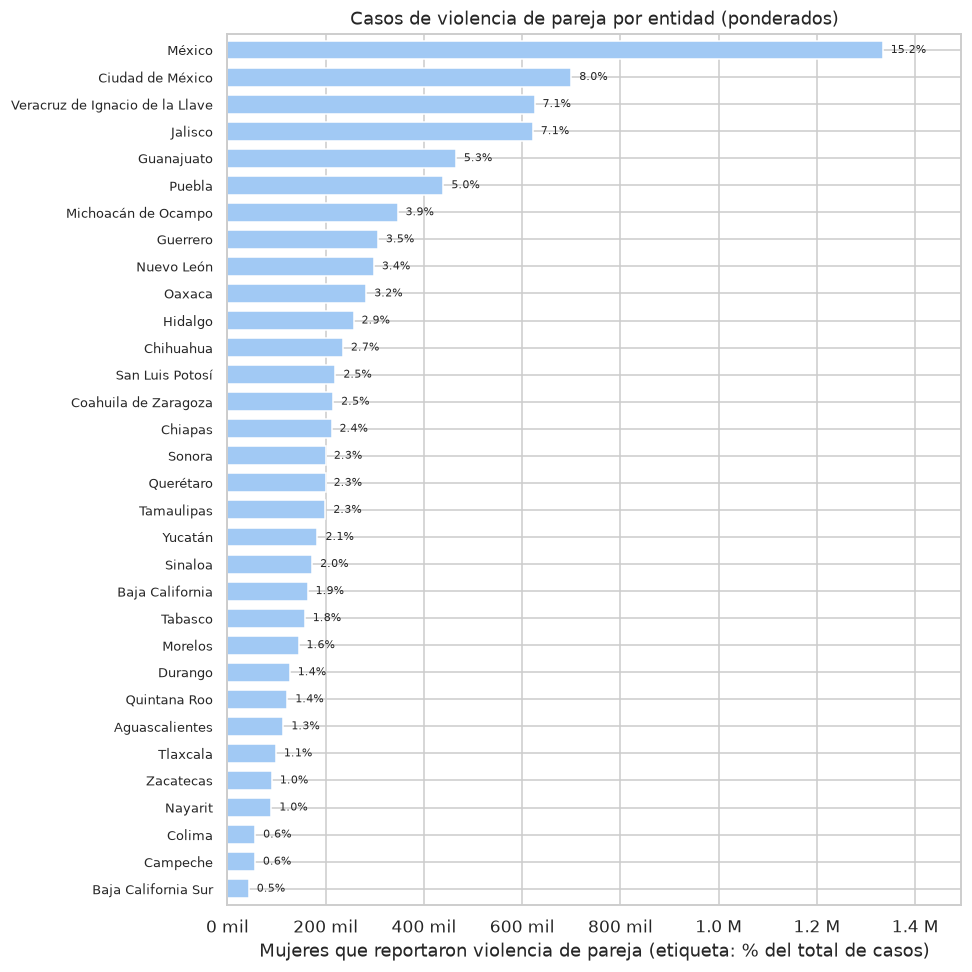

In [6]:
fig = casos_por_entidad(entidades)
guardar_figura(fig, "casos_por_entidad")
plt.show()

### 4.2 Curva de Lorenz

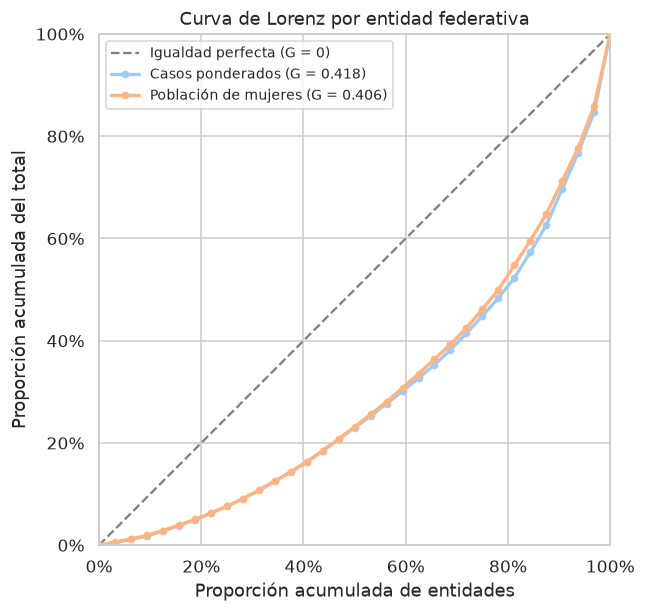

In [7]:
fig = lorenz({
    "Casos ponderados": entidades["casos"].to_numpy(),
    "Población de mujeres": entidades["poblacion"].to_numpy(),
}, "Curva de Lorenz por entidad federativa")
guardar_figura(fig, "lorenz_entidades")
plt.show()

## 5. Interpretación

- Los casos ponderados tienen una concentración moderada (**G = 0.418**; el máximo con 32 entidades es 0.969): las 5 entidades con más casos suman el 42.7 % y la mitad con menos casos, el 23 %.
- La población de mujeres tiene casi el mismo Gini (**0.406**) y su curva casi se superpone: los casos se concentran donde vive más gente.
- Sin ponderar, el Gini de los casos es 0.096 porque la muestra tiene un tamaño parecido por entidad; por eso se pondera.